# UMLR aging-clock audit

## TL;DR

The authors' constrained fit consistently reduces residual-age slope in the
frozen simulations, but it is not a free correction: chronological-age RMSE
increases in most scenarios. The small open-data holdout does not support a
general performance recommendation. This notebook reads only committed
aggregate outputs; it contains no raw methylation or sample identifiers.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"
summary = pd.read_csv(TABLES / "simulation_summary.csv")
real = pd.read_csv(TABLES / "omniage_holdout_metrics.csv")
print(f"Simulation rows: {len(summary)}; real-data methods: {len(real)}")

Simulation rows: 40; real-data methods: 4


## Context & Methods

Four methods are compared on identical train/test splits: raw Lasso, a common
residual correction, linear recalibration, and an independent numerical oracle
for the authors' UMLR constraints. The oracle is fitted on training data only.
It is an audit surface, not a replacement for the official R implementation.

In [2]:
tradeoff = (
    summary.loc[summary["method"].eq("umlr_oracle"), [
        "scenario", "residual_age_slope_mean", "rmse_ratio_vs_raw",
        "association_error_age_adjusted_abs_mean",
        "latent_target_interval_inclusion_rate",
    ]]
    .rename(columns={
        "residual_age_slope_mean": "residual_age_slope",
        "association_error_age_adjusted_abs_mean": "association_error",
        "latent_target_interval_inclusion_rate": "target_CI_inclusion",
    })
)
display(tradeoff.round(3))

,scenario,residual_age_slope,rmse_ratio_vs_raw,association_error,target_CI_inclusion
3,unbiased_predictions,0.000,0.685,0.001,0.967
7,regression_to_mean,0.023,1.296,0.628,0.900
11,range_shift,-0.018,0.731,0.190,1.000
15,heteroscedastic_errors,-0.012,1.088,0.243,0.967
19,age_imbalance,-0.020,1.345,0.325,0.933
23,null_outcome,0.005,1.101,0.244,0.933
27,latent_signal,-0.004,1.098,0.192,1.000
31,age_confounding,-0.002,1.100,0.325,1.000
35,small_calibration_sample,-0.040,1.083,0.189,0.967
39,nonlinear_bias,-0.023,1.080,0.229,1.000


## Data

The simulation benchmark uses ten pre-specified scenarios and 30 replications
per scenario. The real-data demonstration uses the pinned OmniAge lung tutorial
dataset (56 samples, 2,974 methylation features), with a frozen group-by-age
stratified 38/18 split. Feature selection and scaling use training data only.
Only aggregate metrics and age-bin means are retained.

In [3]:
real_view = real[[
    "method", "mae", "rmse", "residual_age_slope",
    "outcome_beta_age_adjusted", "outcome_ci_low_age_adjusted",
    "outcome_ci_high_age_adjusted",
]]
display(real_view.round(3))

,method,mae,rmse,residual_age_slope,outcome_beta_age_adjusted,outcome_ci_low_age_adjusted,outcome_ci_high_age_adjusted
0,raw_lasso,10.238,13.018,-1.190,0.515,-4.552,5.582
1,residual_correction,7.081,9.814,-0.666,0.515,-4.552,5.582
2,linear_recalibration,10.467,13.375,-1.201,0.545,-4.813,5.903
3,umlr_oracle,12.117,15.905,-1.234,1.039,-6.491,8.570


## Results

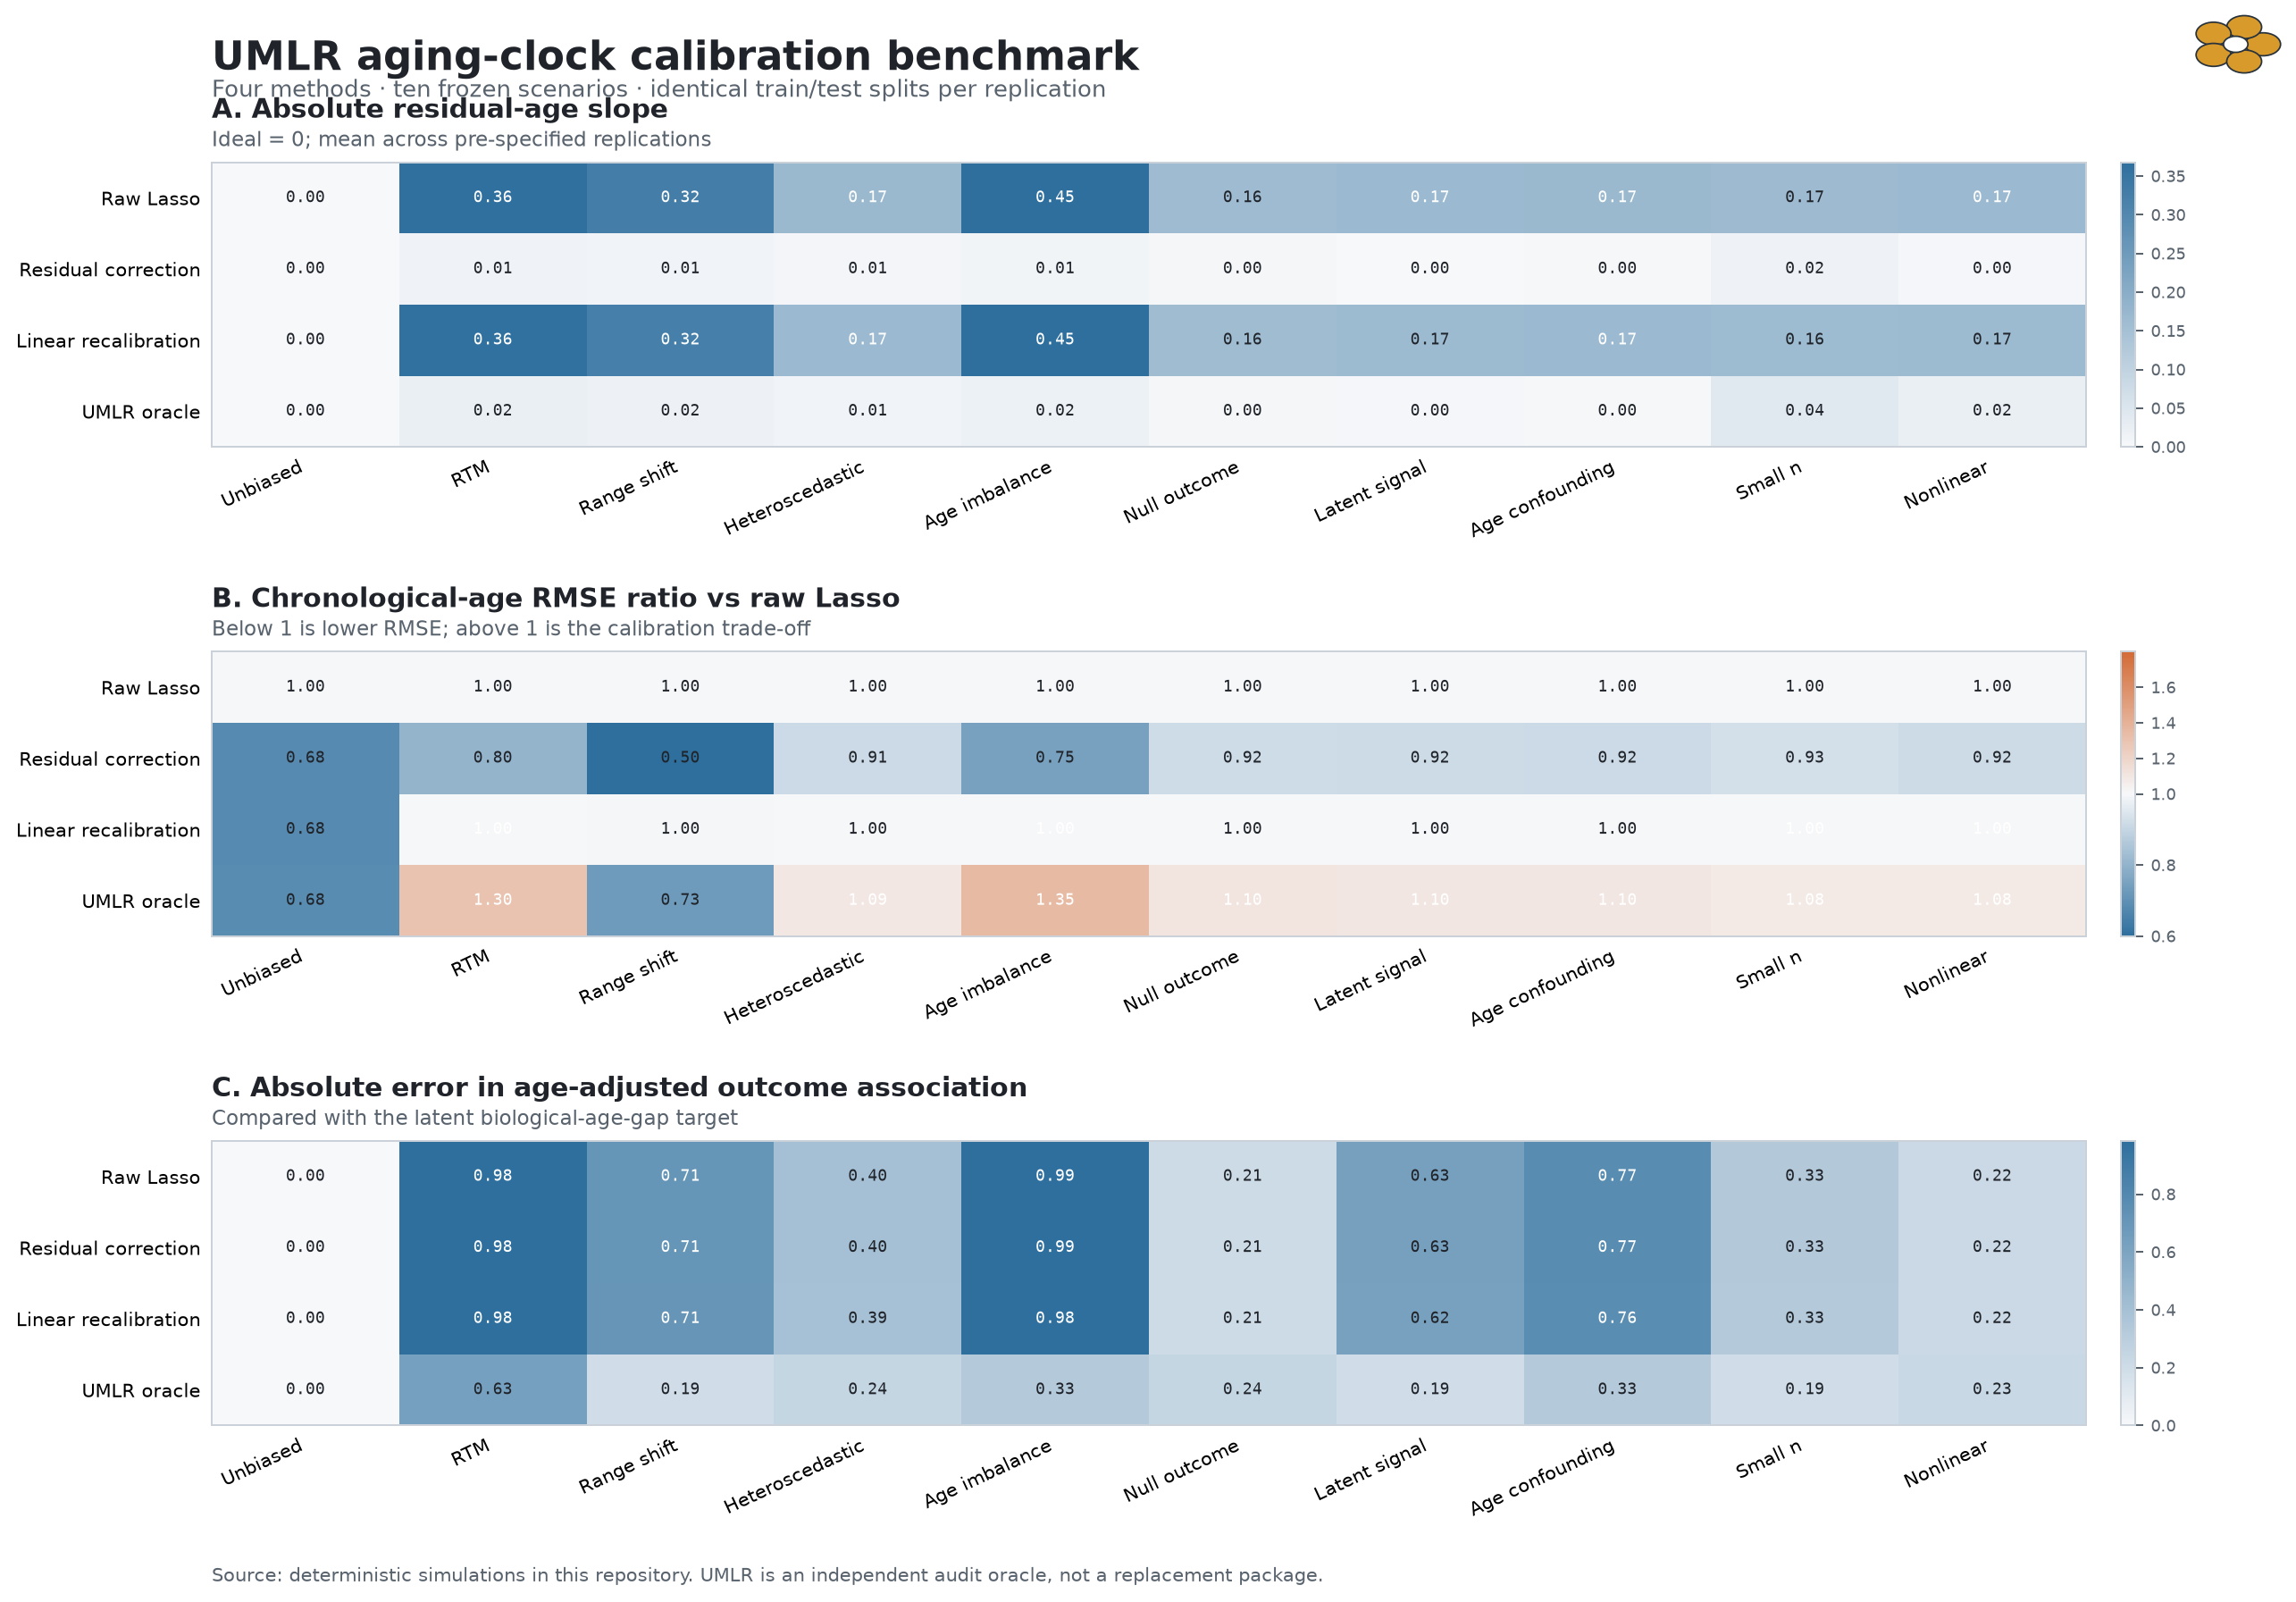

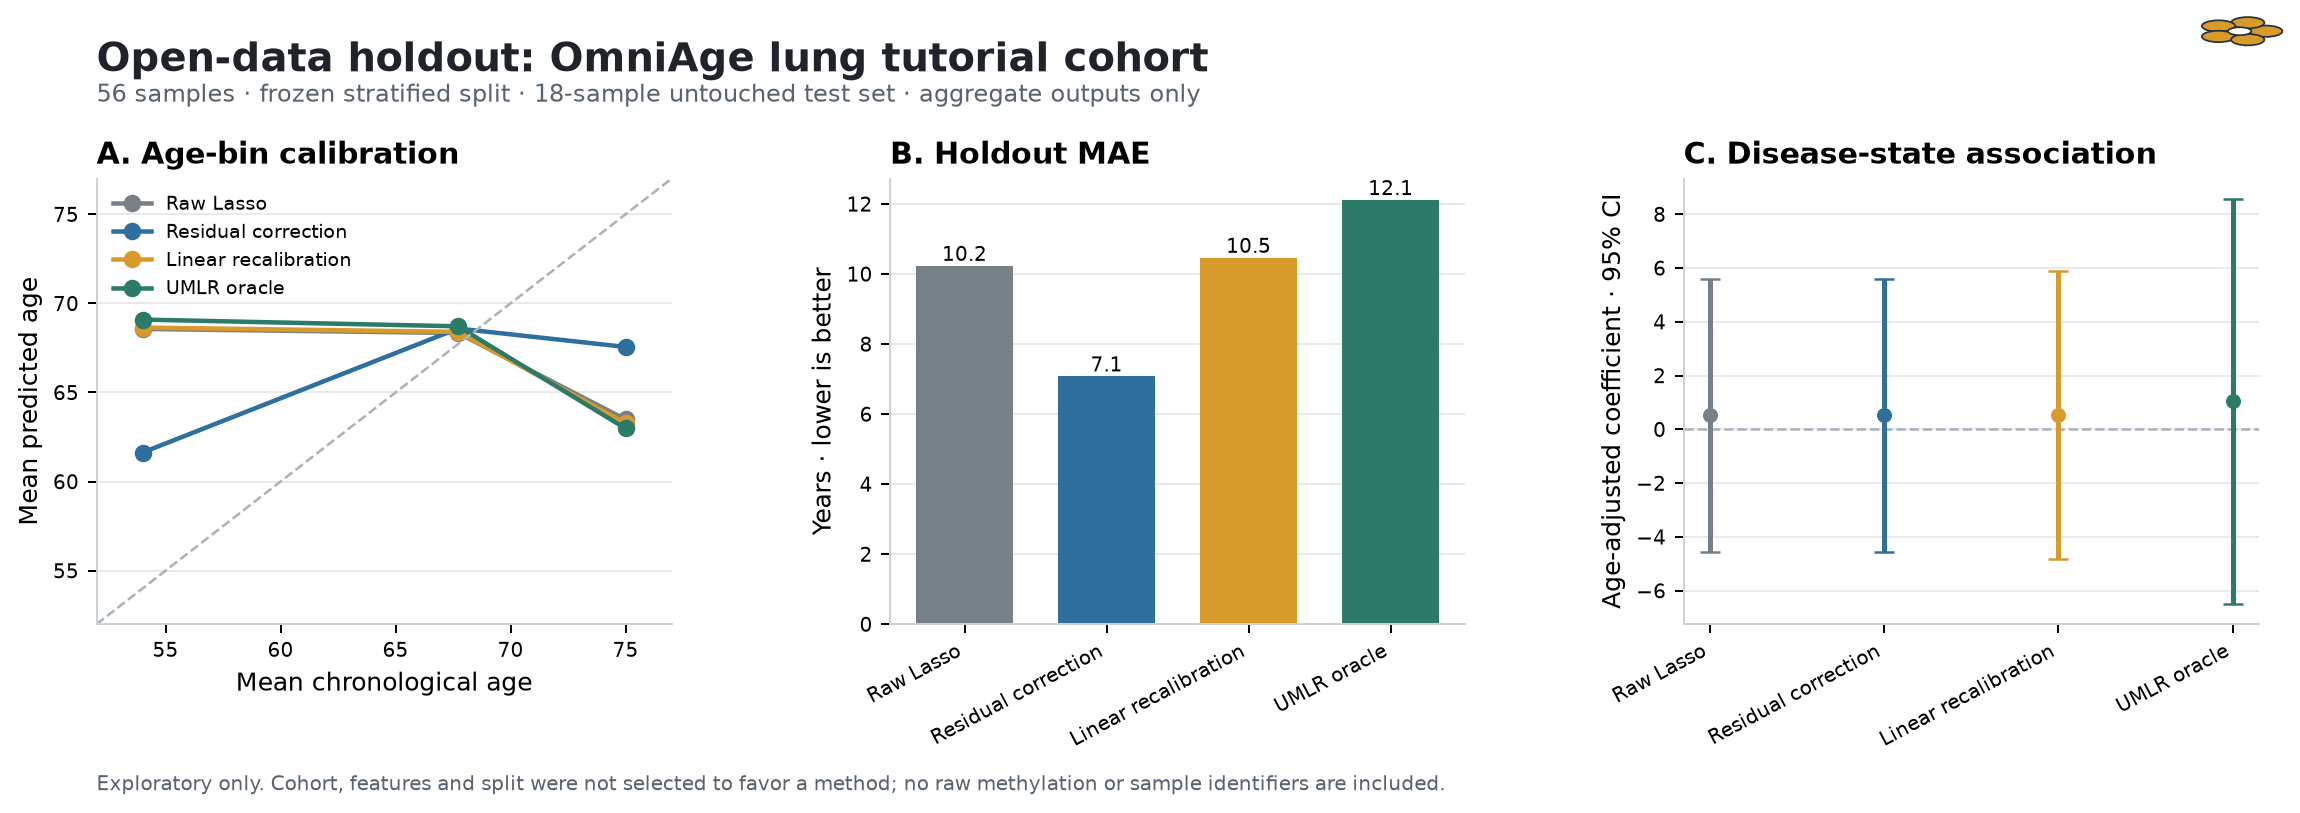

In [4]:
display(Image(filename=str(FIGURES / "simulation-benchmark.png"), width=1100))
display(Image(filename=str(FIGURES / "omniage-holdout.png"), width=1100))

## Takeaways

- UMLR reduced the absolute residual-age slope in every biased simulation.
- Its RMSE exceeded raw Lasso in seven of ten scenarios and rose by about 30%
  under regression-to-the-mean and 35% under age imbalance.
- Association recovery improved in most signal scenarios, but not in the null
  outcome or nonlinear stress test.
- On the small open holdout, all methods generalized poorly; UMLR had the
  highest MAE and the widest disease-state association interval.
- Use therefore requires an external calibration cohort, an explicit
  error-versus-bias trade-off, and validation for the intended downstream
  association. Do not silently refit on test ages.

## Key Assumptions

1. The two-region equations in the preprint are the controlling specification.
2. The independent SciPy oracle is for falsification, not runtime parity with
   the unlicensed official R source.
3. The open lung cohort is exploratory and small; no clinical claim is made.
4. Simulation conclusions are conditional on the frozen data-generating
   processes and penalty value.
5. The authors' controlled UK Biobank and Framingham analyses cannot be
   reproduced here without authorized data access.